```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

(ppd)=
# {index}`Pandas برای داده‌های پانلی <single: Pandas for Panel Data>`

```{index} single: Python; Pandas
```

علاوه بر آنچه در Anaconda موجود است، این سخنرانی به کتابخانه‌های زیر نیاز دارد:

In [1]:
!pip install --upgrade seaborn

ما از import های زیر استفاده می‌کنیم.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

## مروری کلی

در {doc}`سخنرانی پیشین درباره pandas <pandas>`، ما با مجموعه داده‌های ساده کار کردیم.

اقتصادسنجان اغلب نیاز به کار با مجموعه داده‌های پیچیده‌تر مانند پانل‌ها دارند.

وظایف رایج شامل موارد زیر است:

* وارد کردن داده‌ها، تمیز کردن و تغییر شکل دادن آنها در چندین محور.
* انتخاب یک سری زمانی یا مقطع عرضی از یک پانل.
* گروه‌بندی و خلاصه کردن داده‌ها.

`pandas` (مشتق از 'panel' و 'data') شامل ابزارهای قدرتمند و آسان برای حل دقیقاً این نوع مشکلات است.

در ادامه، ما از یک مجموعه داده پانلی از حداقل دستمزدهای واقعی از OECD برای ایجاد موارد زیر استفاده خواهیم کرد:

* آمار خلاصه در ابعاد مختلف داده‌های ما
* یک سری زمانی از میانگین حداقل دستمزد کشورها در مجموعه داده
* برآوردهای چگالی کرنل دستمزدها بر اساس قاره

ما با خواندن داده‌های پانلی فرمت طولانی خود از یک فایل CSV شروع می‌کنیم و `DataFrame` حاصل را با `pivot_table` تغییر شکل می‌دهیم تا یک `MultiIndex` بسازیم.

جزئیات اضافی با استفاده از تابع `merge` پانداز به `DataFrame` ما اضافه خواهد شد، و داده‌ها با تابع `groupby` خلاصه خواهند شد.

## برش و تغییر شکل داده‌ها

ما مجموعه داده‌ای از OECD از حداقل دستمزدهای واقعی در 32 کشور را می‌خوانیم و آن را به `realwage` اختصاص می‌دهیم.

مجموعه داده با لینک زیر قابل دسترسی است:

In [3]:
url1 = 'https://raw.githubusercontent.com/QuantEcon/lecture-python/master/source/_static/lecture_specific/pandas_panel/realwage.csv'

In [4]:
import pandas as pd

# Display 6 columns for viewing purposes
pd.set_option('display.max_columns', 6)

# Reduce decimal points to 2
pd.options.display.float_format = '{:,.2f}'.format

realwage = pd.read_csv(url1)

بیایید نگاهی به آنچه برای کار داریم بیندازیم

In [5]:
realwage.head()  # Show first 5 rows

,Unnamed: 0,Time,Country,Series,Pay period,value
0,0,2006-01-01,Ireland,In 2015 constant prices at 2015 USD PPPs,Annual,"17,132.44"
1,1,2007-01-01,Ireland,In 2015 constant prices at 2015 USD PPPs,Annual,"18,100.92"
2,2,2008-01-01,Ireland,In 2015 constant prices at 2015 USD PPPs,Annual,"17,747.41"
3,3,2009-01-01,Ireland,In 2015 constant prices at 2015 USD PPPs,Annual,"18,580.14"
4,4,2010-01-01,Ireland,In 2015 constant prices at 2015 USD PPPs,Annual,"18,755.83"


داده‌ها در حال حاضر در فرمت طولانی هستند، که تجزیه و تحلیل آن زمانی که چندین بعد برای داده‌ها وجود دارد دشوار است.

ما از `pivot_table` برای ایجاد یک پانل با فرمت عریض، با یک `MultiIndex` برای مدیریت داده‌های چند بعدی بالاتر استفاده خواهیم کرد.

آرگومان‌های `pivot_table` باید داده‌ها (values)، index و ستون‌هایی که در dataframe نتیجه می‌خواهیم را مشخص کنند.

با ارسال یک لیست در columns، می‌توانیم یک `MultiIndex` در محور ستون خود ایجاد کنیم

In [6]:
realwage = realwage.pivot_table(values='value',
                                index='Time',
                                columns=['Country', 'Series', 'Pay period'])
realwage.head()

Country                                   Australia         \
Series     In 2015 constant prices at 2015 USD PPPs          
Pay period                                   Annual Hourly   
Time                                                         
2006-01-01                                20,410.65  10.33   
2007-01-01                                21,087.57  10.67   
2008-01-01                                20,718.24  10.48   
2009-01-01                                20,984.77  10.62   
2010-01-01                                20,879.33  10.57   

Country                                                        ...  \
Series     In 2015 constant prices at 2015 USD exchange rates  ...   
Pay period                                             Annual  ...   
Time                                                           ...   
2006-01-01                                          23,826.64  ...   
2007-01-01                                          24,616.84  ...   
2008-01-01                                          24,185.70  ...   
2009-01-01                                          24,496.84  ...   
2010-01-01                                          24,373.76  ...   

Country                               United States  \
Series     In 2015 constant prices at 2015 USD PPPs   
Pay period                                   Hourly   
Time                                                  
2006-01-01                                     6.05   
2007-01-01                                     6.24   
2008-01-01                                     6.78   
2009-01-01                                     7.58   
2010-01-01                                     7.88   

Country                                                               
Series     In 2015 constant prices at 2015 USD exchange rates         
Pay period                                             Annual Hourly  
Time                                                                  
2006-01-01                                          12,594.40   6.05  
2007-01-01                                          12,974.40   6.24  
2008-01-01                                          14,097.56   6.78  
2009-01-01                                          15,756.42   7.58  
2010-01-01                                          16,391.31   7.88  

[5 rows x 128 columns]

برای فیلتر کردن آسان‌تر داده‌های سری زمانی خود، بعداً، ما index را به یک `DateTimeIndex` تبدیل خواهیم کرد

In [7]:
realwage.index = pd.to_datetime(realwage.index)
type(realwage.index)

pandas.core.indexes.datetimes.DatetimeIndex

ستون‌ها شامل سطوح متعددی از نمایه‌سازی هستند، که به عنوان `MultiIndex` شناخته می‌شوند، با سطوحی که به صورت سلسله مراتبی مرتب شده‌اند (Country > Series > Pay period).

یک `MultiIndex` ساده‌ترین و انعطاف‌پذیرترین راه برای مدیریت داده‌های پانلی در pandas است

In [8]:
type(realwage.columns)

pandas.core.indexes.multi.MultiIndex

In [9]:
realwage.columns.names

FrozenList(['Country', 'Series', 'Pay period'])

مانند قبل، می‌توانیم کشور (سطح بالای `MultiIndex` ما) را انتخاب کنیم

In [10]:
realwage['United States'].head()

Series     In 2015 constant prices at 2015 USD PPPs         \
Pay period                                   Annual Hourly   
Time                                                         
2006-01-01                                12,594.40   6.05   
2007-01-01                                12,974.40   6.24   
2008-01-01                                14,097.56   6.78   
2009-01-01                                15,756.42   7.58   
2010-01-01                                16,391.31   7.88   

Series     In 2015 constant prices at 2015 USD exchange rates         
Pay period                                             Annual Hourly  
Time                                                                  
2006-01-01                                          12,594.40   6.05  
2007-01-01                                          12,974.40   6.24  
2008-01-01                                          14,097.56   6.78  
2009-01-01                                          15,756.42   7.58  
2010-01-01                                          16,391.31   7.88

stacking و unstacking سطوح `MultiIndex` در سراسر این سخنرانی برای تغییر شکل dataframe ما به فرمتی که نیاز داریم استفاده خواهد شد.

`.stack()` پایین‌ترین سطح ستون `MultiIndex` را به index ردیف می‌چرخاند (`.unstack()` در جهت مخالف کار می‌کند - امتحان کنید)

In [11]:
realwage.stack(future_stack=True).head()

Country                                              Australia  \
Series                In 2015 constant prices at 2015 USD PPPs   
Time       Pay period                                            
2006-01-01 Annual                                    20,410.65   
           Hourly                                        10.33   
2007-01-01 Annual                                    21,087.57   
           Hourly                                        10.67   
2008-01-01 Annual                                    20,718.24   

Country                                                                   \
Series                In 2015 constant prices at 2015 USD exchange rates   
Time       Pay period                                                      
2006-01-01 Annual                                              23,826.64   
           Hourly                                                  12.06   
2007-01-01 Annual                                              24,616.84   
           Hourly                                                  12.46   
2008-01-01 Annual                                              24,185.70   

Country                                                Belgium  ...  \
Series                In 2015 constant prices at 2015 USD PPPs  ...   
Time       Pay period                                           ...   
2006-01-01 Annual                                    21,042.28  ...   
           Hourly                                        10.09  ...   
2007-01-01 Annual                                    21,310.05  ...   
           Hourly                                        10.22  ...   
2008-01-01 Annual                                    21,416.96  ...   

Country                                                   United Kingdom  \
Series                In 2015 constant prices at 2015 USD exchange rates   
Time       Pay period                                                      
2006-01-01 Annual                                              20,376.32   
           Hourly                                                   9.81   
2007-01-01 Annual                                              20,954.13   
           Hourly                                                  10.07   
2008-01-01 Annual                                              20,902.87   

Country                                          United States  \
Series                In 2015 constant prices at 2015 USD PPPs   
Time       Pay period                                            
2006-01-01 Annual                                    12,594.40   
           Hourly                                         6.05   
2007-01-01 Annual                                    12,974.40   
           Hourly                                         6.24   
2008-01-01 Annual                                    14,097.56   

Country                                                                   
Series                In 2015 constant prices at 2015 USD exchange rates  
Time       Pay period                                                     
2006-01-01 Annual                                              12,594.40  
           Hourly                                                   6.05  
2007-01-01 Annual                                              12,974.40  
           Hourly                                                   6.24  
2008-01-01 Annual                                              14,097.56  

[5 rows x 64 columns]

همچنین می‌توانیم یک آرگومان برای انتخاب سطحی که می‌خواهیم stack کنیم ارسال کنیم

In [12]:
realwage.stack(level='Country', future_stack=True).head()  # future_stack=True is required until pandas>3.0

Series               In 2015 constant prices at 2015 USD PPPs         \
Pay period                                             Annual Hourly   
Time       Country                                                     
2006-01-01 Australia                                20,410.65  10.33   
           Belgium                                  21,042.28  10.09   
           Brazil                                    3,310.51   1.41   
           Canada                                   13,649.69   6.56   
           Chile                                     5,201.65   2.22   

Series               In 2015 constant prices at 2015 USD exchange rates         
Pay period                                                       Annual Hourly  
Time       Country                                                              
2006-01-01 Australia                                          23,826.64  12.06  
           Belgium                                            20,228.74   9.70  
           Brazil                                              2,032.87   0.87  
           Canada                                             14,335.12   6.89  
           Chile                                               3,333.76   1.42

استفاده از یک `DatetimeIndex` انتخاب یک دوره زمانی خاص را آسان می‌کند.

انتخاب یک سال و stacking کردن دو سطح پایین‌تر `MultiIndex` یک مقطع عرضی از داده‌های پانلی ما ایجاد می‌کند

In [13]:
realwage.loc['2015'].stack(level=(1, 2), future_stack=True).transpose().head() # future_stack=True is required until pandas>3.0

Time                                     2015-01-01         \
Series     In 2015 constant prices at 2015 USD PPPs          
Pay period                                   Annual Hourly   
Country                                                      
Australia                                 21,715.53  10.99   
Belgium                                   21,588.12  10.35   
Brazil                                     4,628.63   2.00   
Canada                                    16,536.83   7.95   
Chile                                      6,633.56   2.80   

Time                                                                  
Series     In 2015 constant prices at 2015 USD exchange rates         
Pay period                                             Annual Hourly  
Country                                                               
Australia                                           25,349.90  12.83  
Belgium                                             20,753.48   9.95  
Brazil                                               2,842.28   1.21  
Canada                                              17,367.24   8.35  
Chile                                                4,251.49   1.81

برای بقیه سخنرانی، ما با یک dataframe از حداقل دستمزدهای واقعی ساعتی در کشورها و زمان، اندازه‌گیری شده در دلار 2015 آمریکا کار خواهیم کرد.

برای ایجاد dataframe فیلتر شده خود (`realwage_f`)، می‌توانیم از متد `xs` برای انتخاب مقادیر در سطوح پایین‌تر در multiindex استفاده کنیم، در حالی که سطوح بالاتر (کشورها در این مورد) را حفظ می‌کنیم

In [14]:
realwage_f = realwage.xs(('Hourly', 'In 2015 constant prices at 2015 USD exchange rates'),
                         level=('Pay period', 'Series'), axis=1)
realwage_f.head()

Country,Australia,Belgium,Brazil,...,Turkey,United Kingdom,United States
Time,,,,,,,
2006-01-01,12.06,9.70,0.87,...,2.27,9.81,6.05
2007-01-01,12.46,9.82,0.92,...,2.26,10.07,6.24
2008-01-01,12.24,9.87,0.96,...,2.22,10.04,6.78
2009-01-01,12.40,10.21,1.03,...,2.28,10.15,7.58
2010-01-01,12.34,10.05,1.08,...,2.30,9.96,7.88


## ادغام Dataframe ها و پر کردن NaN ها

مشابه پایگاه‌های داده رابطه‌ای مانند SQL، pandas متدهای داخلی برای ادغام مجموعه داده‌ها با هم دارد.

با استفاده از اطلاعات کشور از [WorldData.info](https://www.worlddata.info/downloads/)، ما قاره هر کشور را با تابع `merge` به `realwage_f` اضافه خواهیم کرد.

مجموعه داده با لینک زیر قابل دسترسی است:

In [15]:
url2 = 'https://raw.githubusercontent.com/QuantEcon/lecture-python/master/source/_static/lecture_specific/pandas_panel/countries.csv'

In [16]:
worlddata = pd.read_csv(url2, sep=';')
worlddata.head()

,Country (en),Country (de),Country (local),...,Deathrate,Life expectancy,Url
0,Afghanistan,Afghanistan,Afganistan/Afqanestan,...,13.70,51.30,https://www.laenderdaten.info/Asien/Afghanista...
1,Egypt,Ägypten,Misr,...,4.70,72.70,https://www.laenderdaten.info/Afrika/Aegypten/...
2,Åland Islands,Ålandinseln,Åland,...,0.00,0.00,https://www.laenderdaten.info/Europa/Aland/ind...
3,Albania,Albanien,Shqipëria,...,6.70,78.30,https://www.laenderdaten.info/Europa/Albanien/...
4,Algeria,Algerien,Al-Jaza’ir/Algérie,...,4.30,76.80,https://www.laenderdaten.info/Afrika/Algerien/...


ابتدا، ما فقط متغیرهای country و continent را از `worlddata` انتخاب می‌کنیم و ستون را به 'Country' تغییر نام می‌دهیم

In [17]:
worlddata = worlddata[['Country (en)', 'Continent']]
worlddata = worlddata.rename(columns={'Country (en)': 'Country'})
worlddata.head()

,Country,Continent
0,Afghanistan,Asia
1,Egypt,Africa
2,Åland Islands,Europe
3,Albania,Europe
4,Algeria,Africa


می‌خواهیم dataframe جدید خود، `worlddata`، را با `realwage_f` ادغام کنیم.

تابع `merge` پانداز اجازه می‌دهد که dataframe ها با ردیف‌ها به هم متصل شوند.

dataframe های ما با استفاده از نام کشورها ادغام خواهند شد، که نیاز داریم از transpose `realwage_f` استفاده کنیم تا ردیف‌ها در هر دو dataframe با نام کشورها مطابقت داشته باشند

In [18]:
realwage_f.transpose().head()

Time,2006-01-01,2007-01-01,2008-01-01,...,2014-01-01,2015-01-01,2016-01-01
Country,,,,,,,
Australia,12.06,12.46,12.24,...,12.67,12.83,12.98
Belgium,9.70,9.82,9.87,...,10.01,9.95,9.76
Brazil,0.87,0.92,0.96,...,1.21,1.21,1.24
Canada,6.89,6.96,7.24,...,8.22,8.35,8.48
Chile,1.42,1.45,1.44,...,1.76,1.81,1.91


می‌توانیم از left، right، inner، یا outer join برای ادغام مجموعه داده‌های خود استفاده کنیم:

* left join فقط کشورهای مجموعه داده سمت چپ را شامل می‌شود
* right join فقط کشورهای مجموعه داده سمت راست را شامل می‌شود
* outer join کشورهایی را که در مجموعه داده‌های سمت چپ و راست هستند شامل می‌شود
* inner join فقط کشورهای مشترک بین مجموعه داده‌های سمت چپ و راست را شامل می‌شود

به طور پیش‌فرض، `merge` از یک inner join استفاده می‌کند.

در اینجا ما `how='left'` را ارسال خواهیم کرد تا همه کشورها در `realwage_f` را نگه داریم، اما کشورهایی در `worlddata` را که ورودی داده مربوطه در `realwage_f` ندارند دور بیندازیم.

این با سایه قرمز در نمودار زیر نشان داده شده است

```{figure} /_static/lecture_specific/pandas_panel/venn_diag.png
```

همچنین باید مشخص کنیم که نام کشور در هر dataframe کجا قرار دارد، که `key` خواهد بود که برای ادغام dataframe ها 'on' آن استفاده می‌شود.

dataframe 'سمت چپ' ما (`realwage_f.transpose()`) شامل کشورها در index است، بنابراین `left_index=True` را تنظیم می‌کنیم.

dataframe 'سمت راست' ما (`worlddata`) شامل کشورها در ستون 'Country' است، بنابراین `right_on='Country'` را تنظیم می‌کنیم

In [19]:
merged = pd.merge(realwage_f.transpose(), worlddata,
                  how='left', left_index=True, right_on='Country')
merged.head()

,2006-01-01 00:00:00,2007-01-01 00:00:00,2008-01-01 00:00:00,...,2016-01-01 00:00:00,Country,Continent
17.00,12.06,12.46,12.24,...,12.98,Australia,Australia
23.00,9.70,9.82,9.87,...,9.76,Belgium,Europe
32.00,0.87,0.92,0.96,...,1.24,Brazil,South America
100.00,6.89,6.96,7.24,...,8.48,Canada,North America
38.00,1.42,1.45,1.44,...,1.91,Chile,South America


کشورهایی که در `realwage_f` ظاهر شدند اما در `worlddata` نبودند `NaN` در ستون Continent خواهند داشت.

برای بررسی اینکه آیا این اتفاق افتاده است، می‌توانیم از `.isnull()` در ستون continent استفاده کنیم و dataframe ادغام شده را فیلتر کنیم

In [20]:
merged[merged['Continent'].isnull()]

,2006-01-01 00:00:00,2007-01-01 00:00:00,2008-01-01 00:00:00,...,2016-01-01 00:00:00,Country,Continent
NaN,3.42,3.74,3.87,...,5.28,Korea,NaN
NaN,0.23,0.45,0.39,...,0.55,Russian Federation,NaN
NaN,1.50,1.64,1.71,...,2.08,Slovak Republic,NaN


ما سه مقدار گمشده داریم!

یک گزینه برای مقابله با مقادیر NaN ایجاد یک dictionary حاوی این کشورها و قاره‌های مربوطه آنها است.

`.map()` کشورهای موجود در `merged['Country']` را با قاره آنها از dictionary مطابقت می‌دهد.

توجه کنید که کشورهای موجود در dictionary ما با `NaN` نگاشت می‌شوند

In [21]:
missing_continents = {'Korea': 'Asia',
                      'Russian Federation': 'Europe',
                      'Slovak Republic': 'Europe'}

merged['Country'].map(missing_continents)

17.00        NaN
23.00        NaN
32.00        NaN
100.00       NaN
38.00        NaN
108.00       NaN
41.00        NaN
225.00       NaN
53.00        NaN
58.00        NaN
45.00        NaN
68.00        NaN
233.00       NaN
86.00        NaN
88.00        NaN
91.00        NaN
NaN         Asia
117.00       NaN
122.00       NaN
123.00       NaN
138.00       NaN
153.00       NaN
151.00       NaN
174.00       NaN
175.00       NaN
NaN       Europe
NaN       Europe
198.00       NaN
200.00       NaN
227.00       NaN
241.00       NaN
240.00       NaN
Name: Country, dtype: object

نمی‌خواهیم کل سری را با این نگاشت بازنویسی کنیم.

`.fillna()` فقط مقادیر `NaN` در `merged['Continent']` را با نگاشت پر می‌کند، در حالی که سایر مقادیر در ستون بدون تغییر باقی می‌مانند

In [22]:
merged['Continent'] = merged['Continent'].fillna(merged['Country'].map(missing_continents))

# Check for whether continents were correctly mapped

merged[merged['Country'] == 'Korea']

,2006-01-01 00:00:00,2007-01-01 00:00:00,2008-01-01 00:00:00,...,2016-01-01 00:00:00,Country,Continent
NaN,3.42,3.74,3.87,...,5.28,Korea,Asia


همچنین قاره آمریکا را در یک قاره واحد ترکیب خواهیم کرد - این کار تجسم ما را بعداً زیباتر خواهد کرد.

برای انجام این کار، از `.replace()` استفاده خواهیم کرد و از طریق لیستی از مقادیر قاره‌ای که می‌خواهیم جایگزین کنیم حلقه می‌زنیم

In [23]:
replace = ['Central America', 'North America', 'South America']
merged['Continent'] = merged['Continent'].replace(to_replace=replace, value='America')

اکنون که همه داده‌هایی که می‌خواهیم در یک `DataFrame` واحد داریم، آن را به فرم پانلی با یک `MultiIndex` تغییر شکل خواهیم داد.

همچنین باید مطمئن شویم که index را با استفاده از `.sort_index()` مرتب کنیم تا بتوانیم بعداً به طور کارآمد dataframe خود را فیلتر کنیم.

به طور پیش‌فرض، سطوح از بالا به پایین مرتب خواهند شد

In [24]:
merged = merged.set_index(['Continent', 'Country']).sort_index()
merged.head()

2006-01-01  2007-01-01  2008-01-01  ...  2014-01-01  \
Continent Country                                         ...               
America   Brazil            0.87        0.92        0.96  ...        1.21   
          Canada            6.89        6.96        7.24  ...        8.22   
          Chile             1.42        1.45        1.44  ...        1.76   
          Colombia          1.01        1.02        1.01  ...        1.13   
          Costa Rica         NaN         NaN         NaN  ...        2.41   

                      2015-01-01  2016-01-01  
Continent Country                             
America   Brazil            1.21        1.24  
          Canada            8.35        8.48  
          Chile             1.81        1.91  
          Colombia          1.13        1.12  
          Costa Rica        2.56        2.63  

[5 rows x 11 columns]

در حین ادغام، `DatetimeIndex` خود را از دست دادیم، زیرا ستون‌هایی را که در فرمت datetime نبودند ادغام کردیم

In [25]:
merged.columns

Index([2006-01-01 00:00:00, 2007-01-01 00:00:00, 2008-01-01 00:00:00,
       2009-01-01 00:00:00, 2010-01-01 00:00:00, 2011-01-01 00:00:00,
       2012-01-01 00:00:00, 2013-01-01 00:00:00, 2014-01-01 00:00:00,
       2015-01-01 00:00:00, 2016-01-01 00:00:00],
      dtype='object')

اکنون که ستون‌های ادغام شده را به عنوان index تنظیم کرده‌ایم، می‌توانیم یک `DatetimeIndex` با استفاده از `.to_datetime()` دوباره ایجاد کنیم

In [26]:
merged.columns = pd.to_datetime(merged.columns)
merged.columns = merged.columns.rename('Time')
merged.columns

DatetimeIndex(['2006-01-01', '2007-01-01', '2008-01-01', '2009-01-01',
               '2010-01-01', '2011-01-01', '2012-01-01', '2013-01-01',
               '2014-01-01', '2015-01-01', '2016-01-01'],
              dtype='datetime64[ns]', name='Time', freq=None)

`DatetimeIndex` معمولاً در محور ردیف روان‌تر کار می‌کند، بنابراین ما پیش خواهیم رفت و `merged` را transpose خواهیم کرد

In [27]:
merged = merged.transpose()
merged.head()

Continent  America               ...   Europe                     
Country     Brazil Canada Chile  ... Slovenia Spain United Kingdom
Time                             ...                              
2006-01-01    0.87   6.89  1.42  ...     3.92  3.99           9.81
2007-01-01    0.92   6.96  1.45  ...     3.88  4.10          10.07
2008-01-01    0.96   7.24  1.44  ...     3.96  4.14          10.04
2009-01-01    1.03   7.67  1.52  ...     4.08  4.32          10.15
2010-01-01    1.08   7.94  1.56  ...     4.81  4.30           9.96

[5 rows x 32 columns]

## گروه‌بندی و خلاصه کردن داده‌ها

گروه‌بندی و خلاصه کردن داده‌ها می‌تواند به ویژه برای درک مجموعه داده‌های پانلی بزرگ مفید باشد.

یک روش ساده برای خلاصه کردن داده‌ها فراخوانی یک [متد تجمیعی](https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/06_calculate_statistics.html) در dataframe است، مانند `.mean()` یا `.max()`.

به عنوان مثال، می‌توانیم میانگین حداقل دستمزد واقعی را برای هر کشور در دوره 2006 تا 2016 محاسبه کنیم (پیش‌فرض تجمیع بر روی ردیف‌ها است)

In [28]:
merged.mean().head(10)

Continent  Country      
America    Brazil          1.09
           Canada          7.82
           Chile           1.62
           Colombia        1.07
           Costa Rica      2.53
           Mexico          0.53
           United States   7.15
Asia       Israel          5.95
           Japan           6.18
           Korea           4.22
dtype: float64

با استفاده از این سری، می‌توانیم میانگین حداقل دستمزد واقعی را در طول دهه گذشته برای هر کشور در مجموعه داده خود رسم کنیم

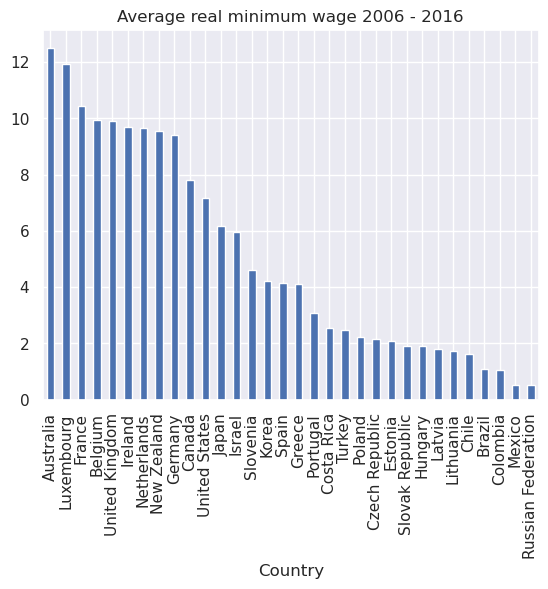

In [29]:
merged.mean().sort_values(ascending=False).plot(kind='bar',
                                                title="Average real minimum wage 2006 - 2016")

# Set country labels
country_labels = merged.mean().sort_values(ascending=False).index.get_level_values('Country').tolist()
plt.xticks(range(0, len(country_labels)), country_labels)
plt.xlabel('Country')

plt.show()

ارسال `axis=1` به `.mean()` بر روی ستون‌ها تجمیع خواهد کرد (میانگین حداقل دستمزد برای همه کشورها در طول زمان را می‌دهد)

In [30]:
merged.mean(axis=1).head()

Time
2006-01-01   4.69
2007-01-01   4.84
2008-01-01   4.90
2009-01-01   5.08
2010-01-01   5.11
dtype: float64

می‌توانیم این سری زمانی را به صورت یک نمودار خطی رسم کنیم

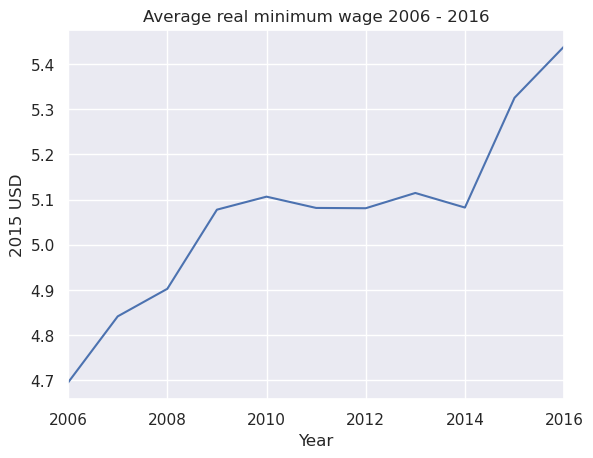

In [31]:
merged.mean(axis=1).plot()
plt.title('Average real minimum wage 2006 - 2016')
plt.ylabel('2015 USD')
plt.xlabel('Year')
plt.show()

همچنین می‌توانیم یک سطح از `MultiIndex` (در محور ستون) را برای تجمیع بر روی آن مشخص کنیم.

در مورد `groupby` ما نیاز داریم از `.T` برای transpose کردن ستون‌ها به ردیف‌ها استفاده کنیم زیرا `pandas` استفاده از `axis=1` را در متد `groupby` منسوخ کرده است.

In [32]:
merged.T.groupby(level='Continent').mean().head()

Time,2006-01-01,2007-01-01,2008-01-01,...,2014-01-01,2015-01-01,2016-01-01
Continent,,,,,,,
America,2.80,2.85,2.99,...,3.22,3.26,3.30
Asia,4.29,4.44,4.45,...,4.86,5.10,5.44
Australia,10.25,10.73,10.76,...,11.25,11.52,11.73
Europe,4.80,4.94,4.99,...,5.17,5.48,5.57


می‌توانیم میانگین حداقل دستمزدها در هر قاره را به عنوان یک سری زمانی رسم کنیم

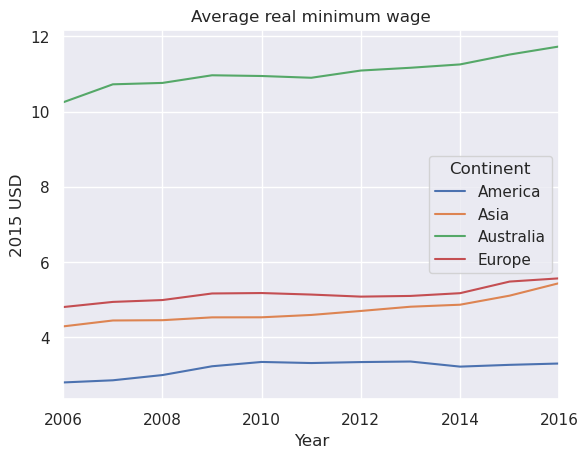

In [33]:
merged.T.groupby(level='Continent').mean().T.plot()
plt.title('Average real minimum wage')
plt.ylabel('2015 USD')
plt.xlabel('Year')
plt.show()

استرالیا را به عنوان یک قاره برای اهداف رسم حذف خواهیم کرد

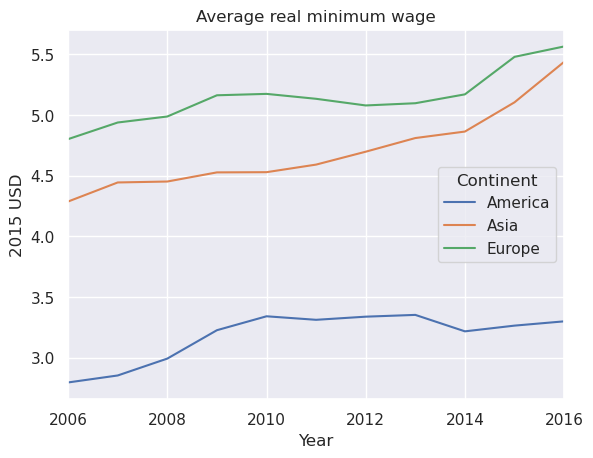

In [34]:
merged = merged.drop('Australia', level='Continent', axis=1)
merged.T.groupby(level='Continent').mean().T.plot()
plt.title('Average real minimum wage')
plt.ylabel('2015 USD')
plt.xlabel('Year')
plt.show()

`.describe()` برای بازیابی سریع تعدادی از آمار خلاصه رایج مفید است

In [35]:
merged.stack(future_stack=True).describe()

Continent,America,Asia,Europe
count,69.00,44.00,200.00
mean,3.19,4.70,5.15
std,3.02,1.56,3.82
min,0.52,2.22,0.23
25%,1.03,3.37,2.02
50%,1.44,5.48,3.54
75%,6.96,5.95,9.70
max,8.48,6.65,12.39


این یک روش ساده شده برای استفاده از `groupby` است.

استفاده از `groupby` به طور کلی از یک فرایند 'تقسیم-اعمال-ترکیب' پیروی می‌کند:

* split: داده‌ها بر اساس یک یا چند کلید گروه‌بندی می‌شوند
* apply: یک تابع به صورت مستقل روی هر گروه فراخوانی می‌شود
* combine: نتایج فراخوانی‌های تابع در یک ساختار داده جدید ترکیب می‌شوند

متد `groupby` اولین مرحله از این فرایند را انجام می‌دهد، یک شیء `DataFrameGroupBy` جدید با داده‌های تقسیم شده به گروه‌ها ایجاد می‌کند.

بیایید `merged` را دوباره بر اساس قاره تقسیم کنیم، این بار با استفاده از تابع `groupby`، و شیء حاصل را `grouped` نامگذاری کنیم

In [36]:
grouped = merged.T.groupby(level='Continent')
grouped

فراخوانی یک متد تجمیعی روی شیء، تابع را به هر گروه اعمال می‌کند، که نتایج آن در یک ساختار داده جدید ترکیب می‌شوند.

به عنوان مثال، می‌توانیم تعداد کشورها در مجموعه داده خود را برای هر قاره با استفاده از `.size()` برگردانیم.

در این مورد، ساختار داده جدید ما یک `Series` است

In [37]:
grouped.size()

Continent
America     7
Asia        4
Europe     19
dtype: int64

با فراخوانی `.get_group()` برای برگرداندن فقط کشورها در یک گروه واحد، می‌توانیم یک برآورد چگالی کرنل از توزیع حداقل دستمزدهای واقعی در 2016 برای هر قاره ایجاد کنیم.

`grouped.groups.keys()` کلیدها را از شیء `groupby` برمی‌گرداند

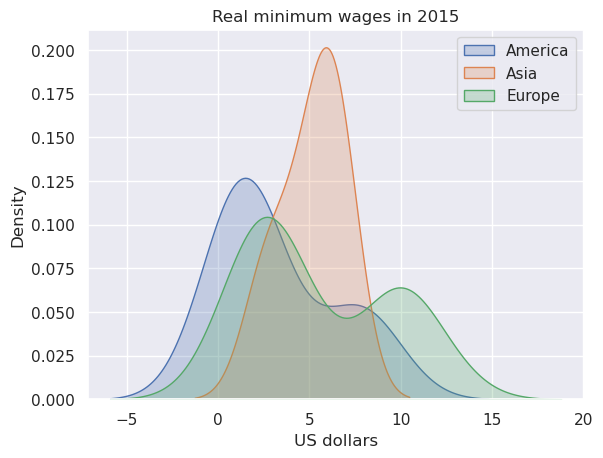

In [38]:
continents = grouped.groups.keys()

for continent in continents:
    sns.kdeplot(grouped.get_group(continent).T.loc['2015'].unstack(), label=continent, fill=True)

plt.title('Real minimum wages in 2015')
plt.xlabel('US dollars')
plt.legend()
plt.show()

## نکات پایانی

این سخنرانی مقدمه‌ای بر برخی از ویژگی‌های پیشرفته‌تر pandas، از جمله multiindex ها، ادغام، گروه‌بندی و رسم نمودار ارائه کرده است.

سایر ابزارهایی که ممکن است در تجزیه و تحلیل داده‌های پانلی مفید باشند شامل [xarray](https://docs.xarray.dev/en/stable/) می‌شوند، یک بسته پایتون که pandas را به ساختارهای داده N بعدی گسترش می‌دهد.

## تمرین‌ها

```{exercise-start}
:label: pp_ex1
```

در این تمرین‌ها، شما با یک مجموعه داده از نرخ‌های اشتغال در اروپا بر اساس سن و جنسیت از [Eurostat](https://ec.europa.eu/eurostat/data/database) کار خواهید کرد.

مجموعه داده با لینک زیر قابل دسترسی است:

In [39]:
url3 = 'https://raw.githubusercontent.com/QuantEcon/lecture-python/master/source/_static/lecture_specific/pandas_panel/employ.csv'

خواندن فایل CSV یک مجموعه داده پانلی در فرمت طولانی را برمی‌گرداند. از `.pivot_table()` برای ساخت یک dataframe با فرمت عریض با یک `MultiIndex` در ستون‌ها استفاده کنید.

با کاوش در dataframe و متغیرهای موجود در سطوح `MultiIndex` شروع کنید.

برنامه‌ای بنویسید که به سرعت همه مقادیر در `MultiIndex` را برمی‌گرداند.

```{exercise-end}
```

```{solution-start} pp_ex1
:class: dropdown
```

In [40]:
employ = pd.read_csv(url3)
employ = employ.pivot_table(values='Value',
                            index=['DATE'],
                            columns=['UNIT','AGE', 'SEX', 'INDIC_EM', 'GEO'])
employ.index = pd.to_datetime(employ.index) # ensure that dates are datetime format
employ.head()

UNIT       Percentage of total population                   ...  \
AGE                   From 15 to 24 years                   ...   
SEX                               Females                   ...   
INDIC_EM                Active population                   ...   
GEO                               Austria Belgium Bulgaria  ...   
DATE                                                        ...   
2007-01-01                          56.00   31.60    26.00  ...   
2008-01-01                          56.20   30.80    26.10  ...   
2009-01-01                          56.20   29.90    24.80  ...   
2010-01-01                          54.00   29.80    26.60  ...   
2011-01-01                          54.80   29.80    24.80  ...   

UNIT                                           Thousand persons           \
AGE                                         From 55 to 64 years            
SEX                                                       Total            
INDIC_EM   Total employment (resident population concept - LFS)            
GEO                                                 Switzerland   Turkey   
DATE                                                                       
2007-01-01                                                NaN   1,282.00   
2008-01-01                                                NaN   1,354.00   
2009-01-01                                                NaN   1,449.00   
2010-01-01                                             640.00   1,583.00   
2011-01-01                                             661.00   1,760.00   

UNIT                       
AGE                        
SEX                        
INDIC_EM                   
GEO        United Kingdom  
DATE                       
2007-01-01       4,131.00  
2008-01-01       4,204.00  
2009-01-01       4,193.00  
2010-01-01       4,186.00  
2011-01-01       4,164.00  

[5 rows x 1440 columns]

این یک مجموعه داده بزرگ است بنابراین کاوش در سطوح و متغیرهای موجود مفید است

In [41]:
employ.columns.names

FrozenList(['UNIT', 'AGE', 'SEX', 'INDIC_EM', 'GEO'])

متغیرهای درون سطوح می‌توانند به سرعت با یک حلقه بازیابی شوند

In [42]:
for name in employ.columns.names:
    print(name, employ.columns.get_level_values(name).unique())

UNIT Index(['Percentage of total population', 'Thousand persons'], dtype='object', name='UNIT')
AGE Index(['From 15 to 24 years', 'From 25 to 54 years', 'From 55 to 64 years'], dtype='object', name='AGE')
SEX Index(['Females', 'Males', 'Total'], dtype='object', name='SEX')
INDIC_EM Index(['Active population', 'Total employment (resident population concept - LFS)'], dtype='object', name='INDIC_EM')
GEO Index(['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic',
       'Denmark', 'Estonia', 'Euro area (17 countries)',
       'Euro area (18 countries)', 'Euro area (19 countries)',
       'European Union (15 countries)', 'European Union (27 countries)',
       'European Union (28 countries)', 'Finland',
       'Former Yugoslav Republic of Macedonia, the', 'France',
       'France (metropolitan)',
       'Germany (until 1990 former territory of the FRG)', 'Greece', 'Hungary',
       'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
       'Malta', 'Neth

```{solution-end}
```

```{exercise-start}
:label: pp_ex2
```

dataframe بالا را فیلتر کنید تا فقط اشتغال را به عنوان درصدی از 'جمعیت فعال' شامل شود.

یک boxplot گروه‌بندی شده با استفاده از `seaborn` از نرخ‌های اشتغال در 2015 بر اساس گروه سنی و جنسیت ایجاد کنید.

```{hint}
:class: dropdown

`GEO` هم مناطق و هم کشورها را شامل می‌شود.
```

```{exercise-end}
```

```{solution-start} pp_ex2
:class: dropdown
```

برای فیلتر کردن آسان بر اساس کشور، `GEO` را به سطح بالا swap کنید و `MultiIndex` را مرتب کنید

In [43]:
employ.columns = employ.columns.swaplevel(0,-1)
employ = employ.sort_index(axis=1)

باید چند مورد در `GEO` که کشور نیستند را حذف کنیم.

یک روش سریع برای خلاص شدن از مناطق EU استفاده از list comprehension برای یافتن مقادیر سطح در `GEO` است که با 'Euro' شروع می‌شوند

In [44]:
geo_list = employ.columns.get_level_values('GEO').unique().tolist()
countries = [x for x in geo_list if not x.startswith('Euro')]
employ = employ[countries]
employ.columns.get_level_values('GEO').unique()

Index(['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic',
       'Denmark', 'Estonia', 'Finland',
       'Former Yugoslav Republic of Macedonia, the', 'France',
       'France (metropolitan)',
       'Germany (until 1990 former territory of the FRG)', 'Greece', 'Hungary',
       'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
       'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania',
       'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey',
       'United Kingdom'],
      dtype='object', name='GEO')

فقط درصد اشتغال در جمعیت فعال را از dataframe انتخاب کنید

In [45]:
employ_f = employ.xs(('Percentage of total population', 'Active population'),
                     level=('UNIT', 'INDIC_EM'),
                     axis=1)
employ_f.head()

GEO                    Austria              ...      United Kingdom        \
AGE        From 15 to 24 years              ... From 55 to 64 years         
SEX                    Females Males Total  ...             Females Males   
DATE                                        ...                             
2007-01-01               56.00 62.90 59.40  ...               49.90 68.90   
2008-01-01               56.20 62.90 59.50  ...               50.20 69.80   
2009-01-01               56.20 62.90 59.50  ...               50.60 70.30   
2010-01-01               54.00 62.60 58.30  ...               51.10 69.20   
2011-01-01               54.80 63.60 59.20  ...               51.30 68.40   

GEO               
AGE               
SEX        Total  
DATE              
2007-01-01 59.30  
2008-01-01 59.80  
2009-01-01 60.30  
2010-01-01 60.00  
2011-01-01 59.70  

[5 rows x 306 columns]

مقدار 'Total' را قبل از ایجاد boxplot گروه‌بندی شده حذف کنید

In [46]:
employ_f = employ_f.drop('Total', level='SEX', axis=1)

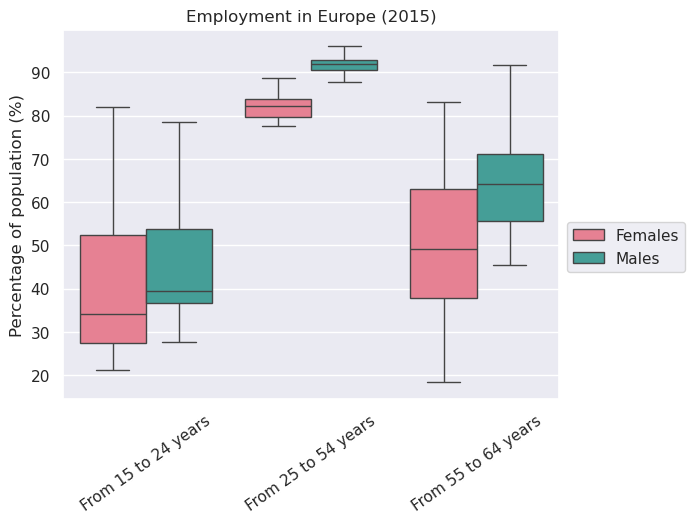

In [47]:
box = employ_f.loc['2015'].unstack().reset_index()
sns.boxplot(x="AGE", y=0, hue="SEX", data=box, palette=("husl"), showfliers=False)
plt.xlabel('')
plt.xticks(rotation=35)
plt.ylabel('Percentage of population (%)')
plt.title('Employment in Europe (2015)')
plt.legend(bbox_to_anchor=(1,0.5))
plt.show()

```{solution-end}
```